### import libraries

In [9]:
import os
import yaml

import numpy as np
import matplotlib.pyplot as plt
from XLO_sim.XLO_sim import XLO_sim
from XLO_sim.Plot import XLO_plot
from XLO_sim import tools

import numpy.fft as fft

import scipy.constants as sp_const
au_in_eV = sp_const.value('atomic unit of energy') / sp_const.value('atomic unit of charge')

import multiprocessing as mp
import shutil

notebook_path = os.path.abspath("__file__")
notebook_directory = os.path.dirname(notebook_path)

### Transmission

In [10]:
tpad = 1000
xpad = 64
ypad = 64

th_show = 2
w_show = 5

thx_show_min = -th_show
thx_show_max = th_show
thy_show_min = -th_show
thy_show_max = th_show
w_show_min = -w_show
w_show_max = w_show

   
def FFT_w_thy(X, field_pstxy):
    coeffs = (2.0 * np.pi * X.hbar, 2.0 * np.pi / X.k0)
    shifts = (X.t_pump_max + tpad * X.dt, X.ymax + ypad * X.dy)
    field_psxty = np.einsum('pstxy->psxty',field_pstxy)
    pad_shape = [(0, 0), (0, 0), (0, 0), (tpad, tpad), (ypad, ypad)]
    domains_sim, meshes_sim, step_sizes_sim = X.optics.nd_kspace(coeffs, (X.tgrid, X.ygrid), (tpad, ypad), (X.dt, X.dy))
    phasors = [np.exp(1j * 2.0 * np.pi * mesh * shift / coeff) for coeff, mesh, shift in zip(coeffs, meshes_sim, shifts)]

    field_psxty_pad = X.optics.my_pad(field_psxty, pad_shape)
    field_fft_pad_phased = X.optics.my_fft_phased(field_psxty_pad, (3, 4), phasors)

    extent_w_thy = [
        np.min(domains_sim[0][tpad:X.tgrid + tpad]), np.max(domains_sim[0][tpad:X.tgrid + tpad]),
        1e3*np.min(domains_sim[1]), 1e3*np.max(domains_sim[1])]

    return extent_w_thy, field_fft_pad_phased 



def I_w(X, zint, isPlot):
    OmegaSF_z_pstxy = X.Omega_pstxyz[:, :, :, :, :, zint]
    extent_w_thy, OmegaSF_z_psxwThy = FFT_w_thy(X, OmegaSF_z_pstxy) 
    I_SF_w_thy = np.real(
        np.einsum('sxwy,sxwy->wy', OmegaSF_z_psxwThy[0,:,:,:,:], OmegaSF_z_psxwThy[1,:,:,::-1,::-1])
    )  

    ygrid_pad = X.ygrid + 2*ypad
    tgrid_pad = X.tgrid + 2*tpad
    womega_ar  = np.linspace(extent_w_thy[0], extent_w_thy[1], tgrid_pad)
    theta_y_ar = np.linspace(extent_w_thy[2], extent_w_thy[3], ygrid_pad)

    dtheta_y = theta_y_ar[1] - theta_y_ar[0] 
    I_int_thy_w = np.real(dtheta_y * np.einsum('wa -> w', I_SF_w_thy))
    I_thy0_w = np.real(I_SF_w_thy[:,int(ygrid_pad/2)])
    
    if isPlot:
        plt.figure()
        plt.plot(womega_ar, I_int_thy_w,'-', label = 'int thy')
        plt.plot(womega_ar, I_thy0_w/max(I_thy0_w) * max(I_int_thy_w),'--', label = 'thy=0')
        plt.ylabel(r'$\int d \theta_y I(\omega,\theta_y$) ')
        plt.xlabel(r'$\omega$ (eV)')
        plt.xlim(w_show_min, w_show_max)
        plt.legend()
        plt.show()
        
    return womega_ar, I_int_thy_w, I_thy0_w 


In [11]:
def yaml_modify_seed_energy(input_yaml_path, output_yaml_path, new_seed_energy):
    # Read the original YAML file
    with open(input_yaml_path, 'r') as file:
        yaml_data = yaml.safe_load(file)
    
    # Modify the seed energy value
    yaml_data['E_seed_uJ'] = new_seed_energy
    
    # Write the modified data to a new YAML file
    with open(output_yaml_path, 'w') as file:
        yaml.safe_dump(yaml_data, file)
    
    print(f"Modified YAML file saved to {output_yaml_path}")


In [12]:
ar_Eseed_values = [40, 20, 10, 5, 1, 0.1]
ar_yaml = []

for Eseed in ar_Eseed_values:
    input_yaml_path = notebook_directory + '/config/Cu-seed-SASE.yaml'
    output_yaml_path = notebook_directory + '/config/Cu-seed-SASE_' + f'{Eseed:.2f}' + 'uJ.yaml'
    yaml_modify_seed_energy(input_yaml_path, output_yaml_path, Eseed)
    ar_yaml.append(output_yaml_path)


Modified YAML file saved to /Users/parkinpham/Programming/Physics/DESY_Internship/XLO_sim_related_notebook/config/Cu-seed-SASE_40.00uJ.yaml
Modified YAML file saved to /Users/parkinpham/Programming/Physics/DESY_Internship/XLO_sim_related_notebook/config/Cu-seed-SASE_20.00uJ.yaml
Modified YAML file saved to /Users/parkinpham/Programming/Physics/DESY_Internship/XLO_sim_related_notebook/config/Cu-seed-SASE_10.00uJ.yaml
Modified YAML file saved to /Users/parkinpham/Programming/Physics/DESY_Internship/XLO_sim_related_notebook/config/Cu-seed-SASE_5.00uJ.yaml
Modified YAML file saved to /Users/parkinpham/Programming/Physics/DESY_Internship/XLO_sim_related_notebook/config/Cu-seed-SASE_1.00uJ.yaml
Modified YAML file saved to /Users/parkinpham/Programming/Physics/DESY_Internship/XLO_sim_related_notebook/config/Cu-seed-SASE_0.10uJ.yaml


### calculating for given amount of repetitions for each yaml

In [13]:
nrep = 3

# Get the number of available CPU cores
num_cpus = mp.cpu_count()

# Set the maximum number of processes to use
num_processes = num_cpus - 1  # Leave one core for system processes or other tasks
print("num_processes", num_processes)

   
data_path = os.path.join(notebook_directory, 'data/' + np.datetime_as_string(np.datetime64('now')))
if not os.path.exists(data_path):
    os.makedirs(data_path)

def run_simulation(yaml, run_path, rep):
    print('repetition ', rep + 1)

    X = XLO_sim(yaml)
    X.random_seed = rep  # Set the random seed for reproducibility
    seed_field = tools.Ocelot_SASE_seed_pstxy(X)
    X.configure(seed_field)
    X.run_3D()

    womega_ar, I_int_thy_w_0, I_thy0_w_0 = I_w(X, 0, False)
    womega_ar, I_int_thy_w_last, I_thy0_w_last = I_w(X, -1, False)

    date_string = np.datetime_as_string(np.datetime64('now'))
    np.savez_compressed(
        os.path.join(run_path, f"run_at_seed_{X.E_seed_uJ:.1f}_uJ__repetition_{rep + 1}_{date_string}.npz"),
        womega_ar=womega_ar,
        I_int_thy_w_0=I_int_thy_w_0,
        I_thy0_w_0=I_thy0_w_0,
        I_int_thy_w_last=I_int_thy_w_last,
        I_thy0_w_last=I_thy0_w_last
    )

def run_repetitions_from_yaml(yaml, nrep, num_processes, data_path):
    date_string = np.datetime_as_string(np.datetime64('now'))
    X = XLO_sim(yaml)

    run_path = os.path.join(data_path, f'runs_seed_{X.E_seed_uJ:.1f}_uJ_{date_string}')
    if not os.path.exists(run_path):
        os.makedirs(run_path)

    shutil.copy2(yaml, run_path)

    # Force the 'fork' start method explicitly so behavior is consistent
    # between macOS (default 'spawn' since Python 3.8) and the Linux
    # cluster (default 'fork'). 'spawn' fails here with AttributeError
    # because it re-imports __main__ to find run_simulation, which does
    # not work for functions defined in a notebook.
    ctx = mp.get_context('fork')
    with ctx.Pool(processes=num_processes) as pool:
        # Run simulations in parallel
        pool.starmap(run_simulation, [(yaml, run_path, rep) for rep in range(nrep)])

if __name__ == '__main__':
    for yaml_value in ar_yaml:
        run_repetitions_from_yaml(yaml_value, nrep, num_processes, data_path)

num_processes 7
norm =  0.6274285868908585
number of pump photons = 0.0e+00
Using Gaussian_pulse_aniso_pump
repetition repetition repetition    312


norm = norm =  norm =   0.62742858689085850.6274285868908585
0.6274285868908585

number of pump photons = 0.0e+00number of pump photons = 0.0e+00number of pump photons = 0.0e+00


Using Gaussian_pulse_aniso_pumpUsing Gaussian_pulse_aniso_pumpUsing Gaussian_pulse_aniso_pump




"scale_kz" will be deprecated, use "grid_z and grid_kz" instead
"scale_kz" will be deprecated, use "grid_z and grid_kz" instead
"scale_kz" will be deprecated, use "grid_z and grid_kz" instead


number of seed photons = 3.1e+10number of seed photons = 3.1e+10number of seed photons = 3.1e+10


Simulation startup: seededSimulation startup: seededSimulation startup: seeded


Seed field will be converted to RH and LH polarizationSeed field will be converted to RH and LH polarization

Seed field will be converted to RH and LH polarization
Configured XLO simulation in simultaneous modeConfigured XLO simulation in simultaneous mode
Configured XLO simulation in simultaneous mode

Slice: Slice:  0
Slice:   00

Slice: Slice:  Slice:   111


Slice:  2Slice: 
 2Slice: 
 2
Slice:  3Slice: 
 3
Slice:  3
Slice:  4
Slice:  4
Slice:  4
Slice:  5
Slice:  5
Slice:  5
Slice:  6
Slice:  6
Slice:  6
Slice:  7
Slice:  Slice: 7 
7
Slice:  8
Slice:  8
Slice:  8
Slice:  9
Slice: Slice:   99

Slice:  10
Slice: Slice:   10
10
Slice: Slice:   1111

Slice:  11
Slice:  12
Slice:  12
Slice:  12
Slice:  13
Slice:  13
Slice:  13
Slice:  14
Slice:  14
Slice:  14
norm =  0.6274285868908585
number of pump photons

"scale_kz" will be deprecated, use "grid_z and grid_kz" instead
"scale_kz" will be deprecated, use "grid_z and grid_kz" instead
"scale_kz" will be deprecated, use "grid_z and grid_kz" instead


number of seed photons = 1.6e+10number of seed photons = 1.6e+10number of seed photons = 1.6e+10


Simulation startup: seededSimulation startup: seededSimulation startup: seeded


Seed field will be converted to RH and LH polarizationSeed field will be converted to RH and LH polarizationSeed field will be converted to RH and LH polarization


Configured XLO simulation in simultaneous modeConfigured XLO simulation in simultaneous modeConfigured XLO simulation in simultaneous mode


Slice: Slice:   Slice:  00

0
Slice:  1
Slice:  1
Slice:  1
Slice:  2
Slice:  2
Slice:  2
Slice:  3
Slice:  3
Slice:  3
Slice:  4
Slice:  4
Slice:  4
Slice:  5
Slice:  5
Slice:  5
Slice:  6
Slice:  6
Slice:  6
Slice:  7Slice: 
 7
Slice:  7
Slice:  Slice: 8 
8
Slice:  8
Slice:  Slice: 9
 9
Slice:  9
Slice:  10
Slice:  10
Slice:  10
Slice:  11
Slice:  11
Slice:  11
Slice:  12
Slice:  12
Slice:  12
Slice:  13
Slice:  13
Slice:  13
Slice:  14
Slice:  14
Slice:  14
norm =  0.6274285868908585
number of pump photons

...


number of seed photons = 7.8e+08

"scale_kz" will be deprecated, use "grid_z and grid_kz" instead


number of seed photons = 7.8e+08

number of seed photons = 7.8e+08
Simulation startup: seededSimulation startup: seeded

Seed field will be converted to RH and LH polarizationSeed field will be converted to RH and LH polarizationSimulation startup: seeded


Configured XLO simulation in simultaneous modeSeed field will be converted to RH and LH polarizationConfigured XLO simulation in simultaneous mode


Slice: Slice: Configured XLO simulation in simultaneous mode 0
 0

Slice:  0
Slice:  1
Slice:  1
Slice:  1
Slice:  2
Slice: Slice:   22

Slice:  3
Slice:  3Slice: 
 3
Slice:  4
Slice:  4
Slice:  4
Slice:  5
Slice:  5
Slice:  5
Slice:  6
Slice:  6
Slice:  6
Slice:  7
Slice:  7
Slice:  7
Slice: Slice:   88

Slice:  8
Slice:  9
Slice:  9
Slice:  9
Slice:  10
Slice:  10
Slice:  10
Slice:  11
Slice:  11
Slice:  11
Slice:  12
Slice:  12
Slice:  12
Slice:  13
Slice:  13
Slice:  13
Slice:  14
Slice:  14
Slice:  14
norm =  0.6274285868908585
number of pump photons = 0.0e+00
Using Gaussian_pulse_

"scale_kz" will be deprecated, use "grid_z and grid_kz" instead
"scale_kz" will be deprecated, use "grid_z and grid_kz" instead
"scale_kz" will be deprecated, use "grid_z and grid_kz" instead


number of seed photons = 7.8e+07number of seed photons = 7.8e+07number of seed photons = 7.8e+07


Simulation startup: seeded
Seed field will be converted to RH and LH polarization
Simulation startup: seededSimulation startup: seeded

Configured XLO simulation in simultaneous modeSeed field will be converted to RH and LH polarization

Seed field will be converted to RH and LH polarization
Configured XLO simulation in simultaneous mode
Slice: Configured XLO simulation in simultaneous mode 0

Slice:  0
Slice:  0
Slice: Slice:  Slice:  11 

1
Slice:  2
Slice:  2
Slice:  2
Slice:  3
Slice:  3
Slice:  3
Slice:  4
Slice:  4
Slice:  4
Slice:  5
Slice:  5
Slice:  5
Slice:  6
Slice:  6
Slice:  6
Slice:  7
Slice:  7
Slice:  7
Slice:  8
Slice:  8
Slice:  8
Slice:  9
Slice:  9
Slice:  9
Slice:  10
Slice:  10Slice: 
 10
Slice:  11
Slice:  Slice: 11 
11
Slice:  12
Slice: Slice:  12 12

Slice:  13
Slice: Slice:  13 13

Slice:  14
Slice:  14
Slice:  14


### reading and plotting

In [14]:
figs_path = os.path.join(notebook_directory, 'figs')
if not os.path.exists(figs_path):
    os.makedirs(figs_path)

In [15]:
from collections import OrderedDict


def data_from_folder(folder_path):

    # print(os.listdir(folder_path))

    # Initialize the top-level dictionary to store accumulated arrays for each E_seed
    accumulated_arrays = {}

    for runs_Eseed_folder in os.listdir(folder_path):
        # Specify the path to the folder containing the saved files
        runs_path = folder_path + '/' + runs_Eseed_folder

        # Find the YAML file in the folder
        yaml_file = None
        for file_name in os.listdir(runs_path):
            if file_name.endswith('.yaml'):
                yaml_file = os.path.join(runs_path, file_name)
                break

        if yaml_file is None:
            print(f"No YAML file found in {runs_path}")
            continue

        # Read the YAML file to get the E_seed value
        with open(yaml_file, 'r') as f:
            yaml_data = yaml.safe_load(f)
            E_seed_value = yaml_data['E_seed_uJ']
            
            # seed_FEL_bandwidth = yaml_data['seed_FEL_bandwidth']
            tgrid = yaml_data['tgrid']
            xgrid = yaml_data['xgrid']
            ygrid = yaml_data['ygrid']
            zgrid = yaml_data['zgrid']
            sigma1_Ka1_2p3 = yaml_data['sigma1_Ka1_2p3']
            sigma1_Ka1_other = yaml_data['sigma1_Ka1_other']
            seed_duration_FWHM_t = yaml_data['seed_duration_FWHM_t']
            
            aux_data = [tgrid, xgrid, ygrid, zgrid, sigma1_Ka1_2p3, sigma1_Ka1_other, seed_duration_FWHM_t]

        # Initialize variables to store the accumulated arrays for the current E_seed
        if E_seed_value not in accumulated_arrays:
            accumulated_arrays[E_seed_value] = {}

        # Iterate over all files in the folder
        for file_name in os.listdir(runs_path):
            # Check if the file is a numpy savez_compressed file
            if file_name.endswith('.npz'):
                # Load the file
                file_path = os.path.join(runs_path, file_name)
                data = np.load(file_path)

                # Iterate over all arrays in the loaded file
                for array_name in data.files:
                    # Accumulate the arrays by averaging them
                    if array_name in accumulated_arrays[E_seed_value]:
                        accumulated_arrays[E_seed_value][array_name] += data[array_name]
                    else:
                        accumulated_arrays[E_seed_value][array_name] = data[array_name]

        # Divide each accumulated array by the number of files to get the average
        num_files = len([file_name for file_name in os.listdir(runs_path) if file_name.endswith('.npz')])
        # print(f'E_seed: {E_seed_value}, num_files: {num_files}')
        for array_name in accumulated_arrays[E_seed_value]:
            accumulated_arrays[E_seed_value][array_name] /= num_files

    # Sort the accumulated arrays by E_seed value
    sorted_accumulated_arrays = OrderedDict(sorted(accumulated_arrays.items(), key=lambda x: x[0], reverse=True))

    # Example of how to access the accumulated arrays for a specific E_seed
    # for E_seed_value, arrays in sorted_accumulated_arrays.items():
    #     print(f'E_seed: {E_seed_value}')
    #     for array_name, array_data in arrays.items():
    #         print(f'  Array name: {array_name}, shape: {array_data.shape}')
    
    return sorted_accumulated_arrays, aux_data, num_files

E_seed: 40
E_seed: 20
E_seed: 10
E_seed: 5
E_seed: 1
E_seed: 0.1


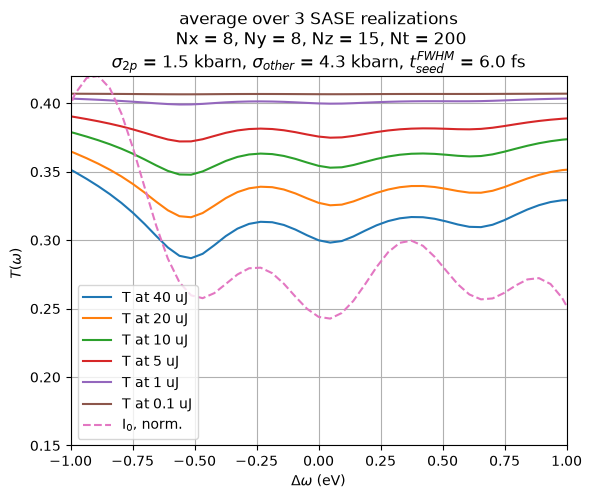

In [16]:
Tshow_min = 0.15#0.4
Tshow_max = 0.42#0.5
w_show = 1
w_show_min = -w_show
w_show_max = w_show

def plotting_data_folder(folder_path, Tshow_min, Tshow_max):
    
    sorted_accumulated_arrays, aux_data, num_files = data_from_folder(folder_path)
    
    tgrid, xgrid, ygrid, zgrid, sigma1_Ka1_2p3, sigma1_Ka1_other, seed_duration_FWHM_t = aux_data

    plt.figure()
    
    str_pars_grid = " Nx = " + str(xgrid) + ", Ny = " + str(ygrid) + ", Nz = " + str(zgrid) + ", Nt = " + str(tgrid)
    str_pars_calc = r'$\sigma_{2p}$ = ' + f'{1e7*sigma1_Ka1_2p3:.1f}' + ' kbarn' + \
    r', $\sigma_{other}$ = ' + f'{1e7*sigma1_Ka1_other:.1f}' +' kbarn' + \
    r', $t_{seed}^{FWHM}$ = ' + f'{seed_duration_FWHM_t:.1f}' +' fs'
    
    plt.title('average over ' + str(num_files) + ' SASE realizations' + '\n'
    + str_pars_grid + '\n' + str_pars_calc
     )          
             


    for E_seed_value, arrays in sorted_accumulated_arrays.items():
        print(f'E_seed: {E_seed_value}')

        womega_ar = arrays['womega_ar']
        I_int_thy_w_last = arrays['I_int_thy_w_last']
        I_int_thy_w_0 = arrays['I_int_thy_w_0']
        
        I_int_thy_w_last = I_int_thy_w_last + 0.00001 * max(I_int_thy_w_last)
        I_int_thy_w_0 = I_int_thy_w_0 + 0.00001 * max(I_int_thy_w_0)
        
        Tint_w = I_int_thy_w_last / I_int_thy_w_0
        
        plt.plot(womega_ar, Tint_w, label = 'T at '+ str(E_seed_value) + ' uJ')
    plt.plot(womega_ar, Tshow_min + (Tshow_max-Tshow_min) * arrays['I_int_thy_w_0']/max(arrays['I_int_thy_w_0']),'--', label = r'I$_0$, norm.')
    plt.ylabel(r'$T(\omega$) ')
    plt.xlabel(r'$\Delta\omega$ (eV)')
    plt.xlim(w_show_min, w_show_max)
    plt.ylim(Tshow_min,Tshow_max)
    plt.legend()
    plt.grid(True)
    plt.savefig(figs_path + '/' + str_pars_calc + '.pdf')
    plt.show()
    
plotting_data_folder(data_path, Tshow_min, Tshow_max)
